In [6]:
import numpy as np
import pandas as pd
from pathlib import Path
import json

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

COVERAGE_TARGETS = [0.1, 0.25, 0.5, 0.75]
LLR_KEY  = "StandardLLR"
FLLR_KEY = "FilteredLLR"
PRIOR_TYPE = "domain_knowledge"

THESIS = dict(
    font_family    = "Georgia",
    font_size_base = 11,
    font_size_title = 13,
    font_size_annot = 9,
    dpi            = 300,
    color_pos      = "#2A9D8F",
    color_neg      = "#E63946",
    color_zero     = "#FFFFFF",
)

cmap_thesis = mcolors.LinearSegmentedColormap.from_list(
    "thesis_div",
    [THESIS["color_neg"], THESIS["color_zero"], THESIS["color_pos"]],
    N=256,
)

def pauc(fpr, tpr, fpr_max=0.2):
    fpr, tpr = np.array(fpr), np.array(tpr)
    mask = fpr <= fpr_max + 1e-9
    f, t = fpr[mask], tpr[mask]
    if len(f) < 2:
        return np.nan
    return np.trapezoid(t, f) / fpr_max

def compute_delta_auc(json_path, prior_type=PRIOR_TYPE):
    with open(json_path) as f:
        raw = json.load(f)
    data = raw[0] if isinstance(raw, list) else raw

    prior_entry = next(e for e in data["results"] if e["prior_type"] == prior_type)

    result = {}
    for cov_entry in prior_entry["coverage_results"]:
        target = float(cov_entry["target_coverage"])
        if target not in COVERAGE_TARGETS:
            continue
        result[target] = {}
        for t_entry in cov_entry["t_size_estimates"]:
            m = t_entry["target_size_multiplier"]
            llr_aucs, fllr_aucs = [], []
            for bn_result in t_entry["bn_results"]:
                metrics = bn_result["avg_metrics"]
                if LLR_KEY in metrics and FLLR_KEY in metrics:
                    llr_aucs.append(pauc(metrics[LLR_KEY]["fpr"], metrics[LLR_KEY]["tpr"]))
                    fllr_aucs.append(pauc(metrics[FLLR_KEY]["fpr"], metrics[FLLR_KEY]["tpr"]))
            if llr_aucs:
                result[target][m] = round(np.mean(fllr_aucs) - np.mean(llr_aucs), 4)
            else:
                result[target][m] = np.nan
    return result

EXP_ORDER = [
    "asia", "cancer", "earthquake", "sachs", "survey",
    "alarm", "child", "insurance",
    "exp1", "exp2",
    "exp1.1", "exp1.2", "exp1.3",
    "exp2.1", "exp2.2", "exp2.3",
    "exp3.1", "exp3.2", "exp3.3",
    "exp4.1", "exp4.2", "exp4.3",
    "exp5.1", "exp5.2", "exp5.3",
]

def reindex_experiments(df):
    """Reorder experiments following EXP_ORDER"""
    present = [e for e in EXP_ORDER if e in df.index]
    return df.loc[present]

In [7]:
def load_records(exp_root):
    """Load ΔAUC records from all experiment_results.json under exp_root."""
    records = []
    for jp in sorted(Path(exp_root).rglob("experiment_results.json")):
        name = jp.parent.name
        try:
            result = compute_delta_auc(jp)
            for cov, mults in result.items():
                for m, delta in mults.items():
                    records.append({
                        "Experiment": name,
                        "Coverage":   f"{int(cov*100)}%",
                        "Multiplier": m,
                        "ΔAUC":       delta,
                    })
        except Exception as e:
            print(f"ERROR {name}: {e}")
    return pd.DataFrame(records)


df_balanced   = load_records("./experiments/eval_balanced")
df_unbalanced = load_records("./experiments/eval_unbalanced")

def make_pivot(df):
    return df.pivot_table(
        index=["Experiment", "Coverage"],
        columns="Multiplier",
        values="ΔAUC",
    ).rename(columns=lambda m: f"mul={m}")

df_pivot_balanced   = make_pivot(df_balanced)
df_pivot_unbalanced = make_pivot(df_unbalanced)

print("df_pivot_balanced:  ", df_pivot_balanced.shape)
print("df_pivot_unbalanced:", df_pivot_unbalanced.shape)

df_pivot_balanced:   (100, 5)
df_pivot_unbalanced: (100, 5)


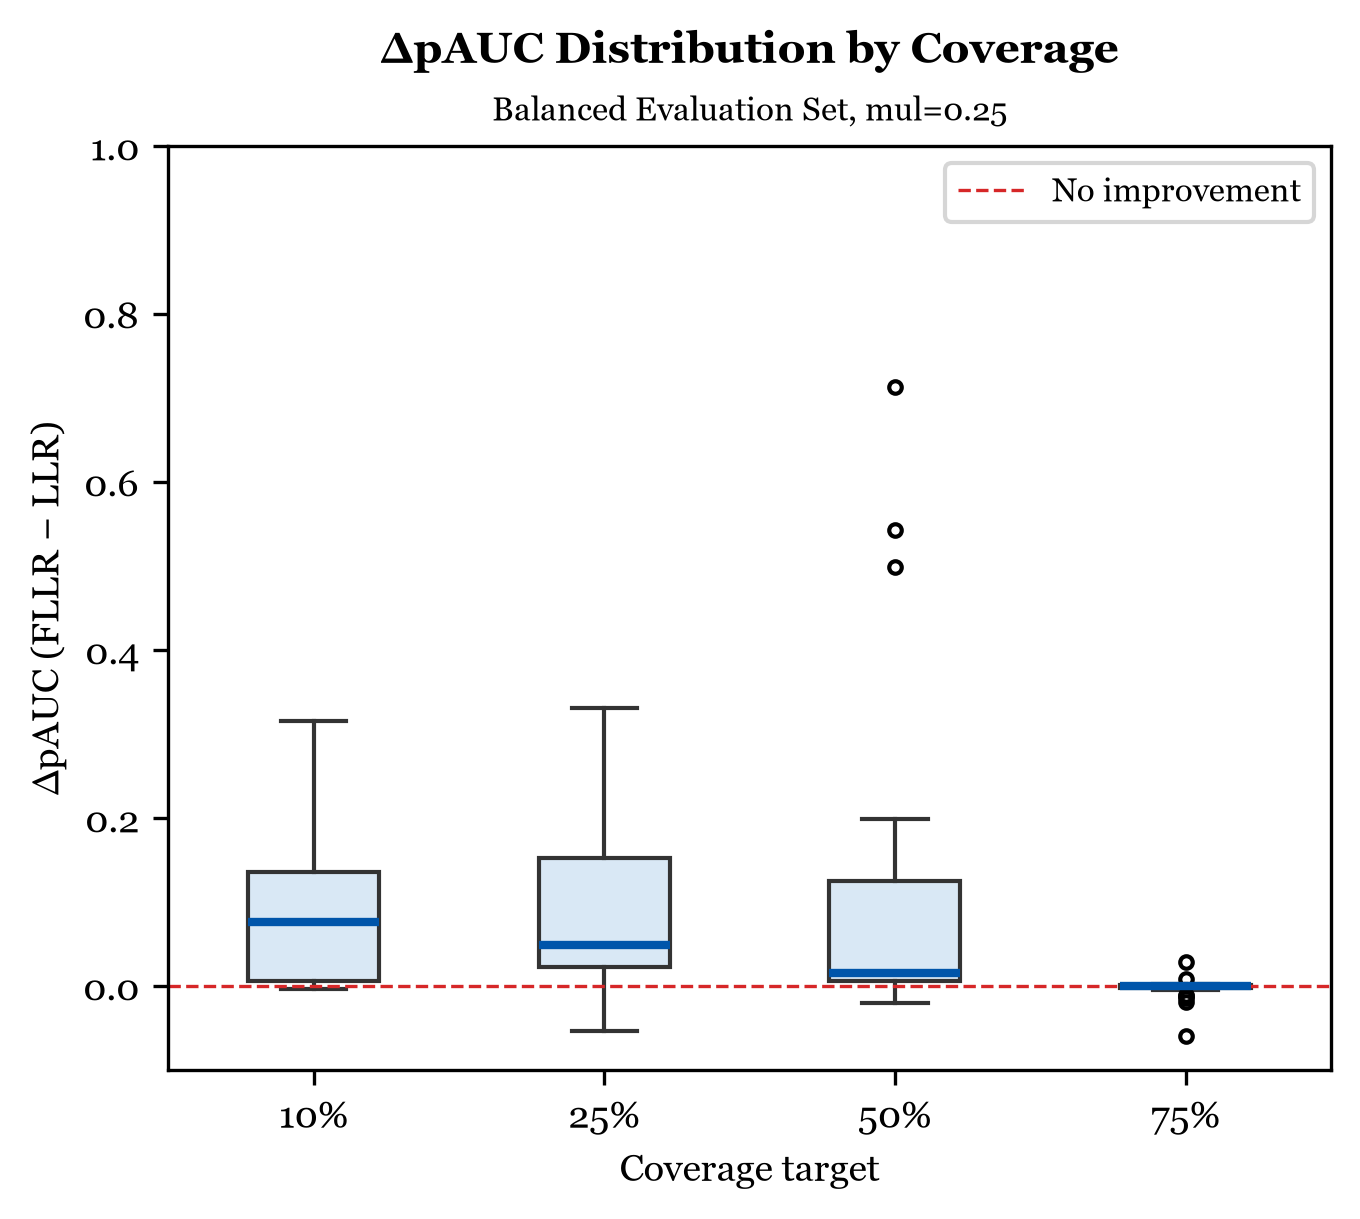

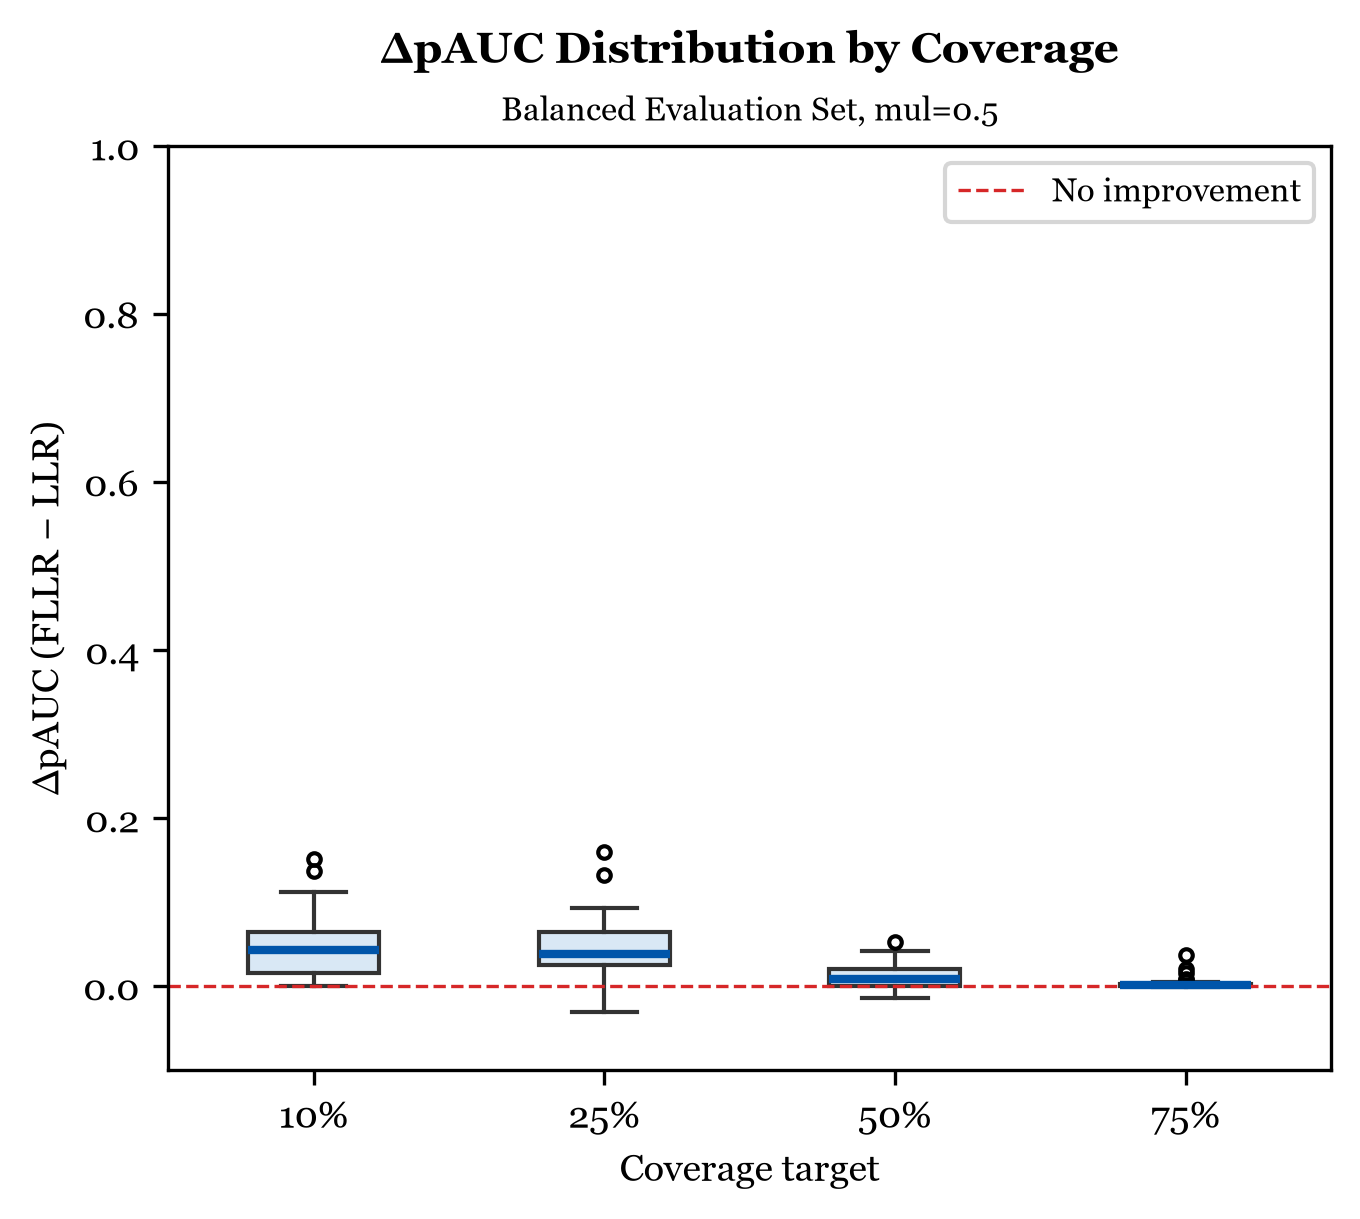

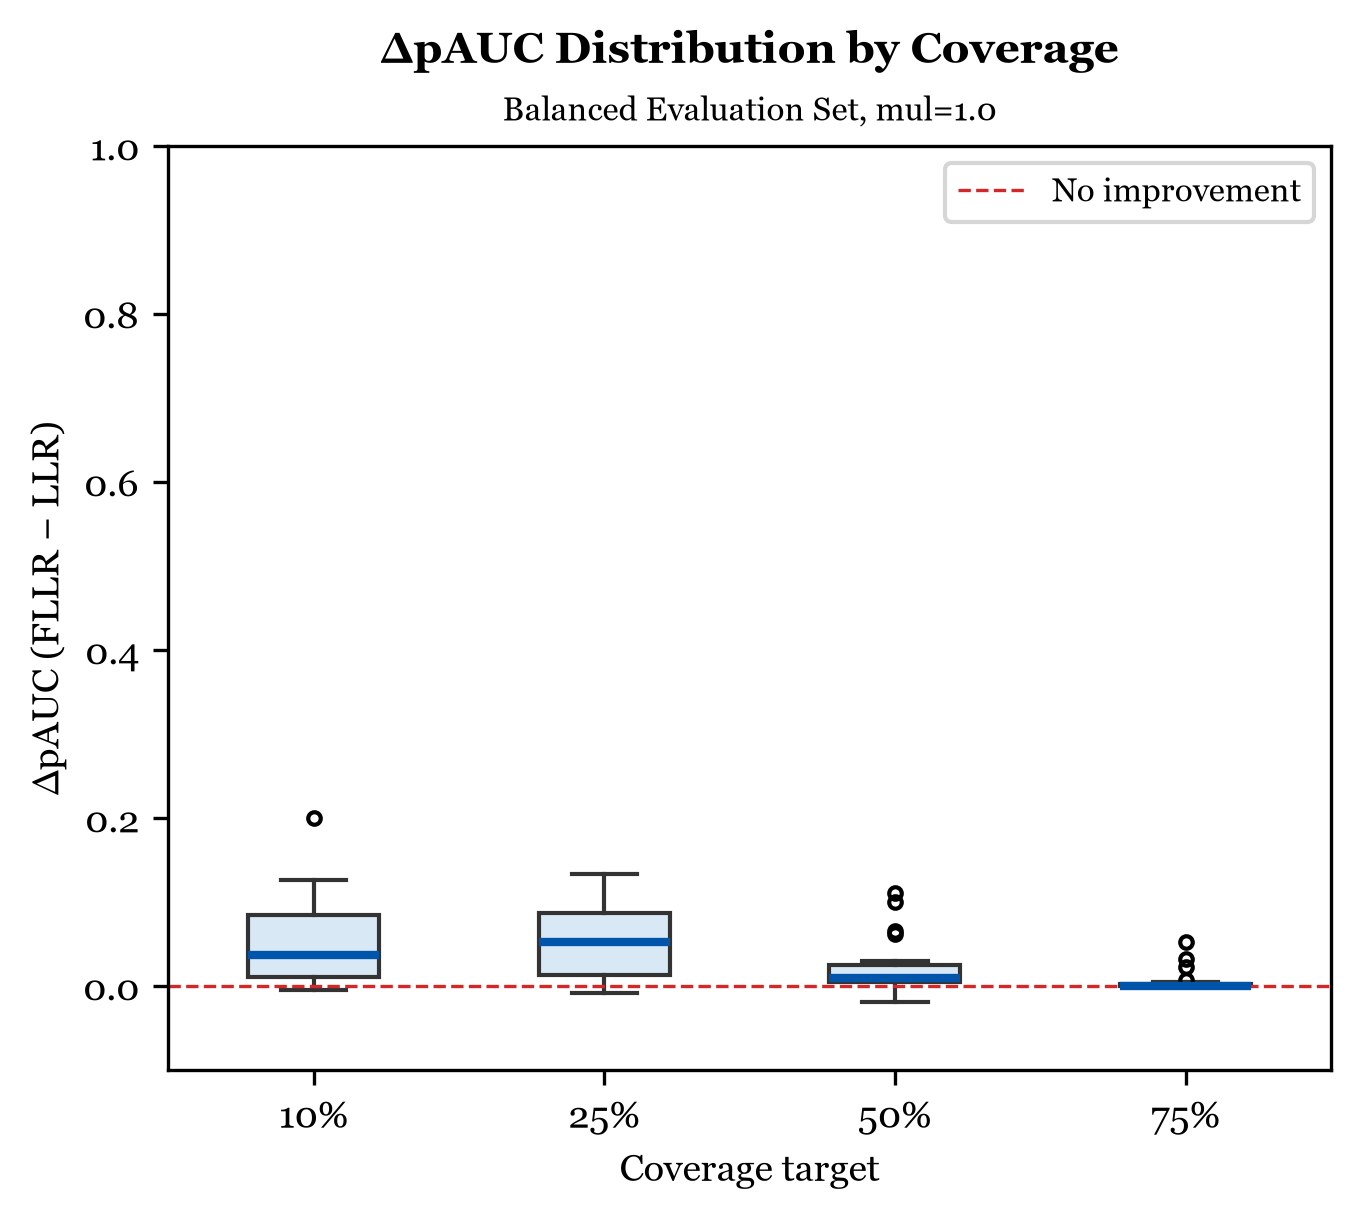

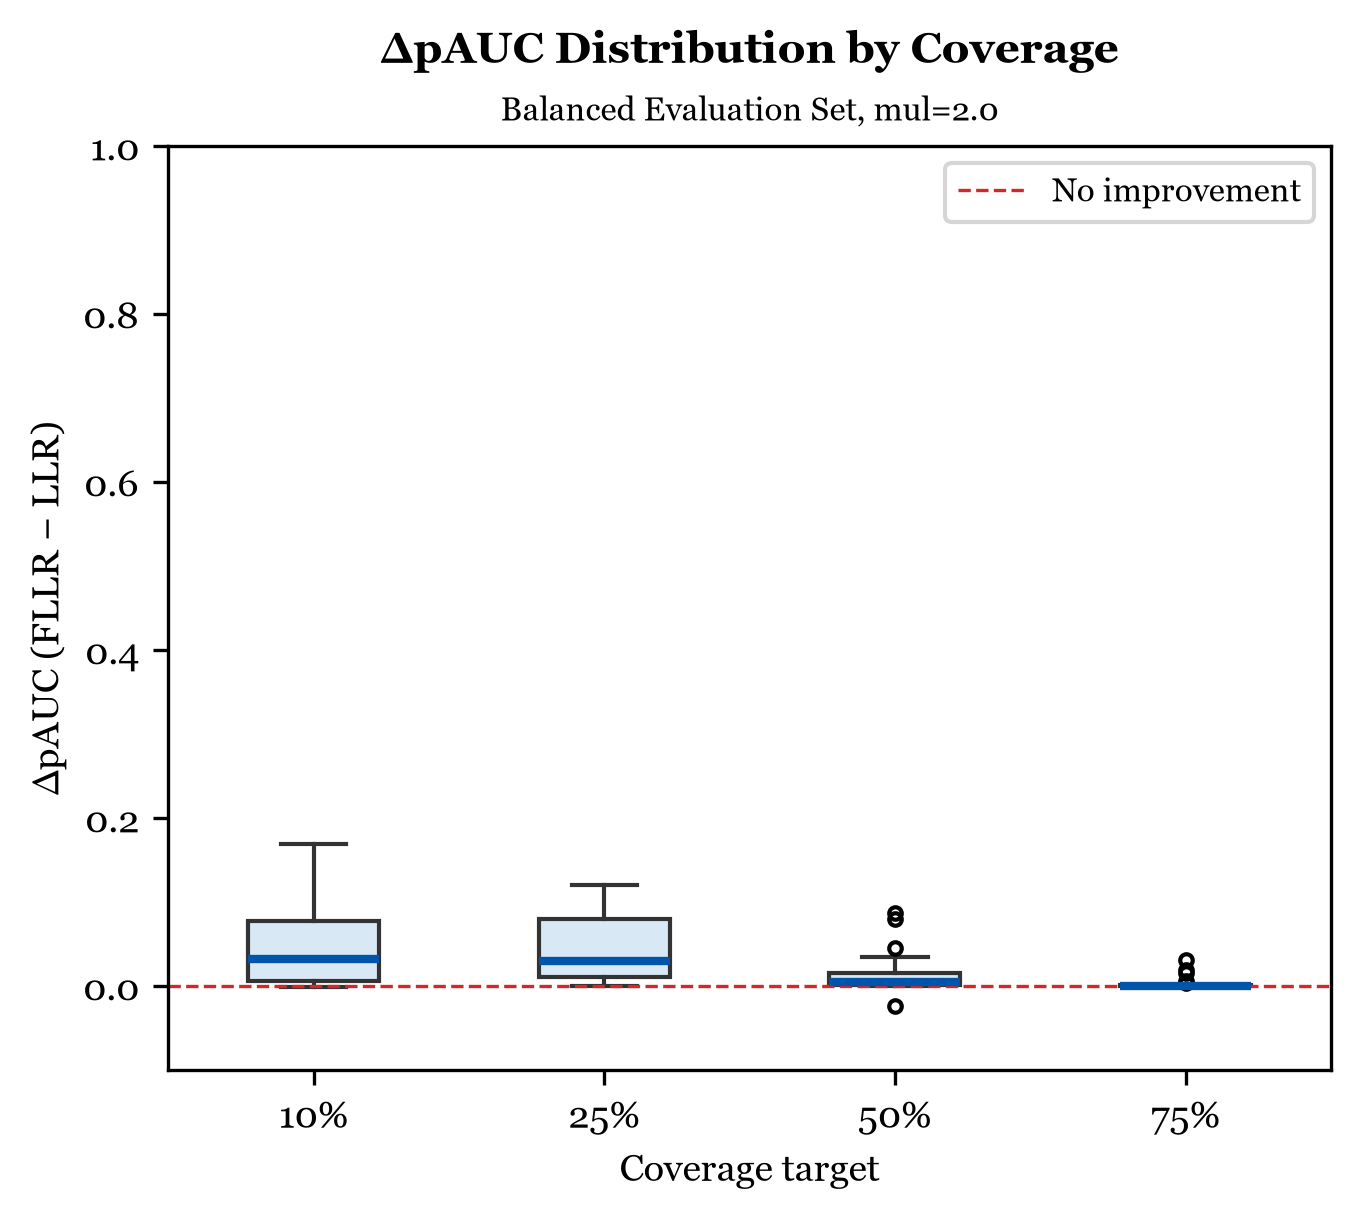

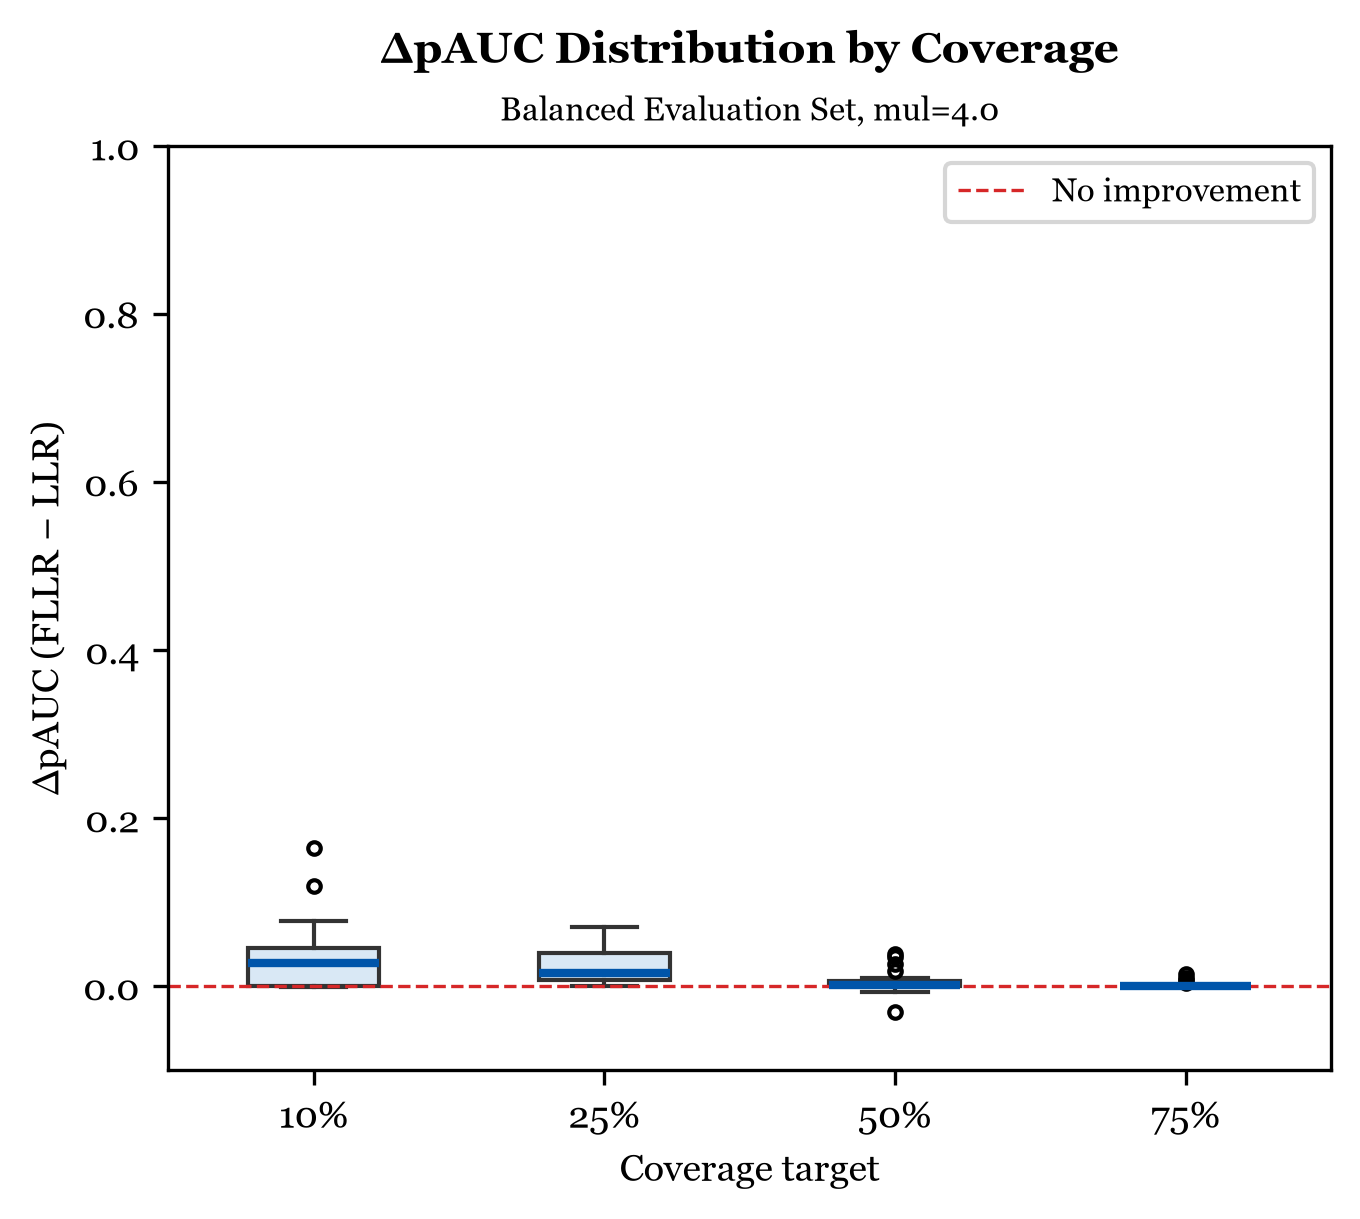

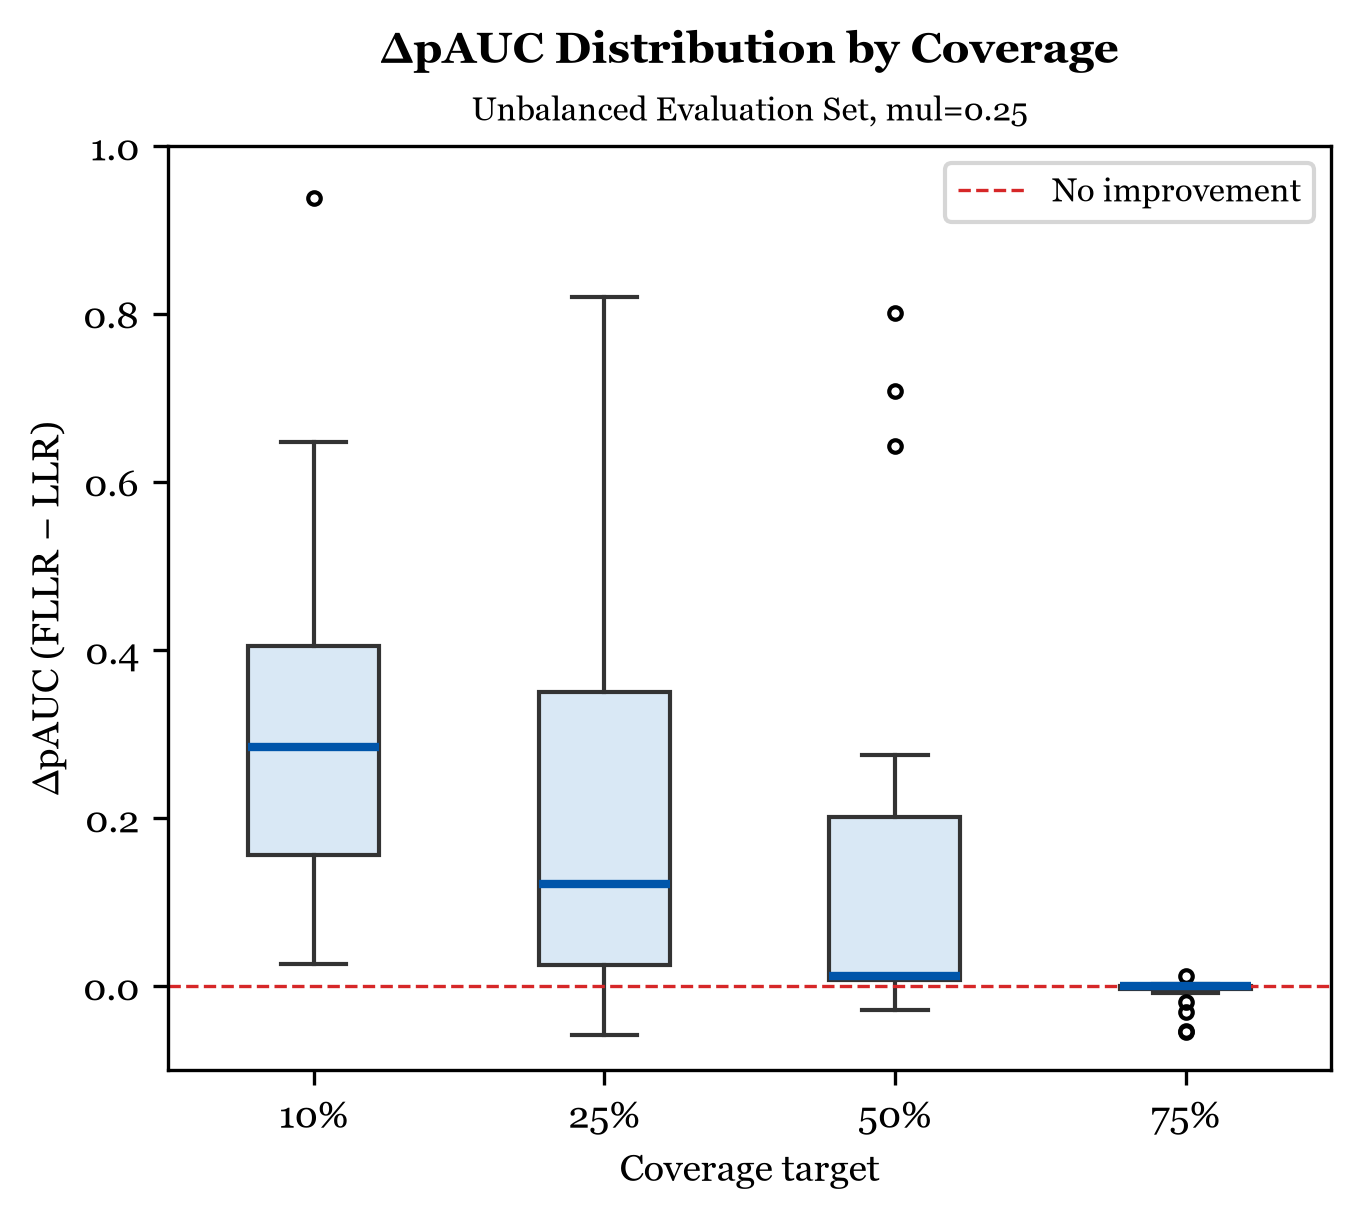

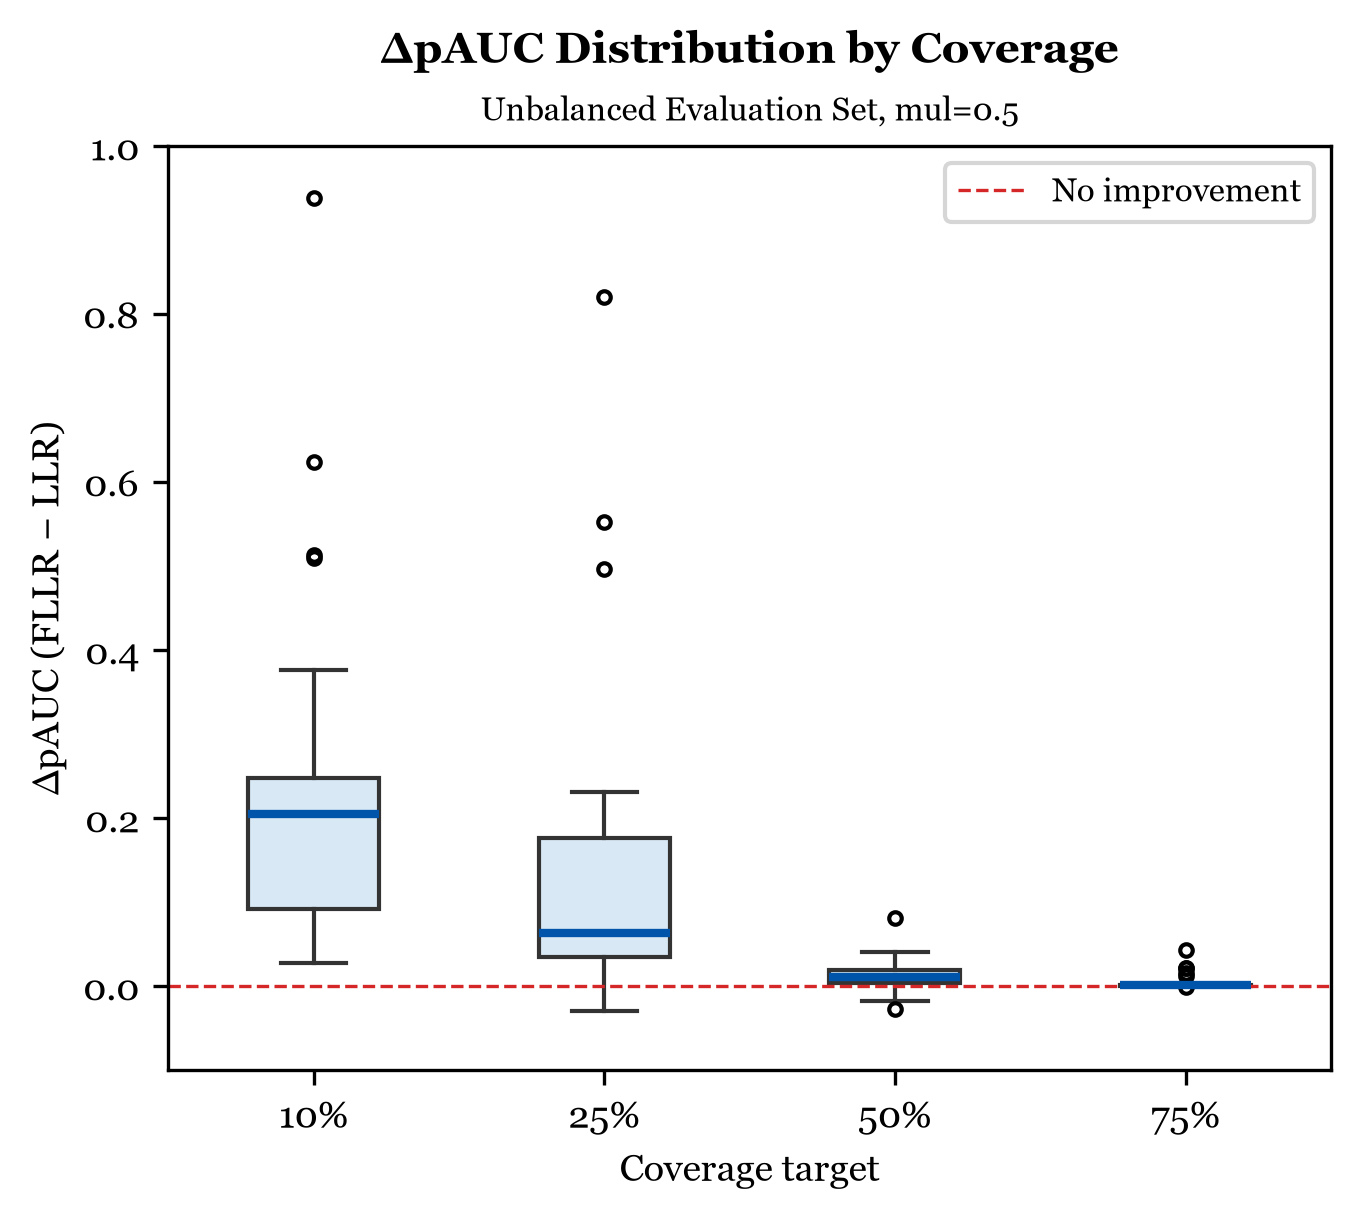

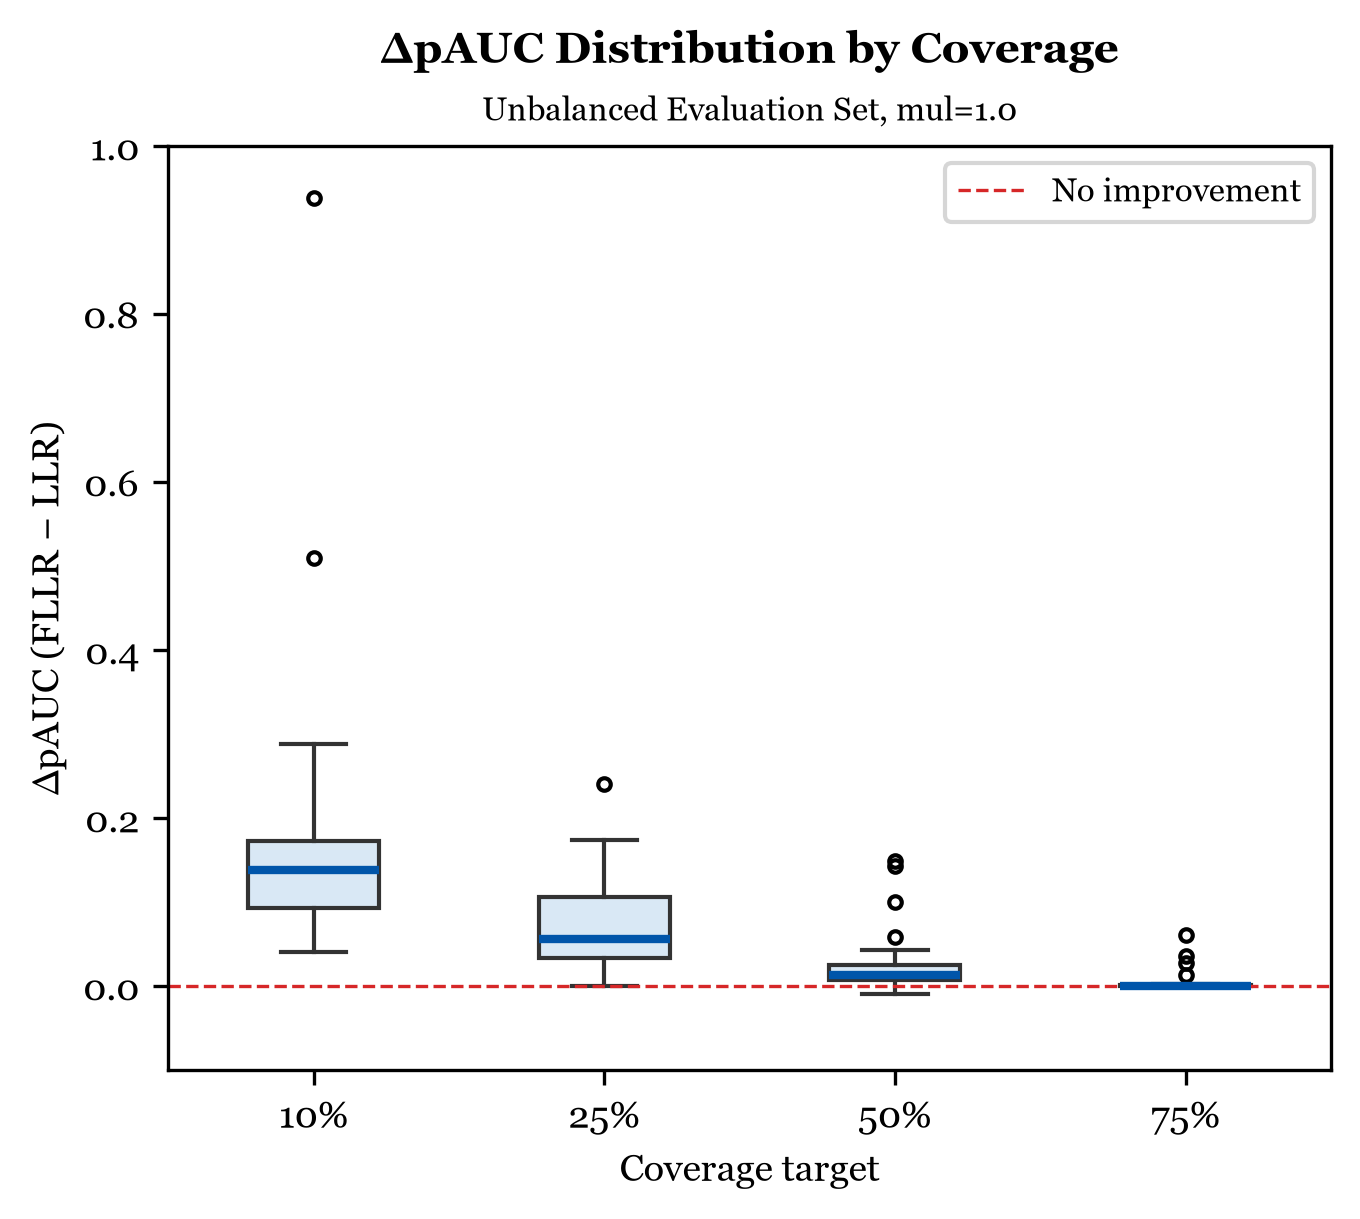

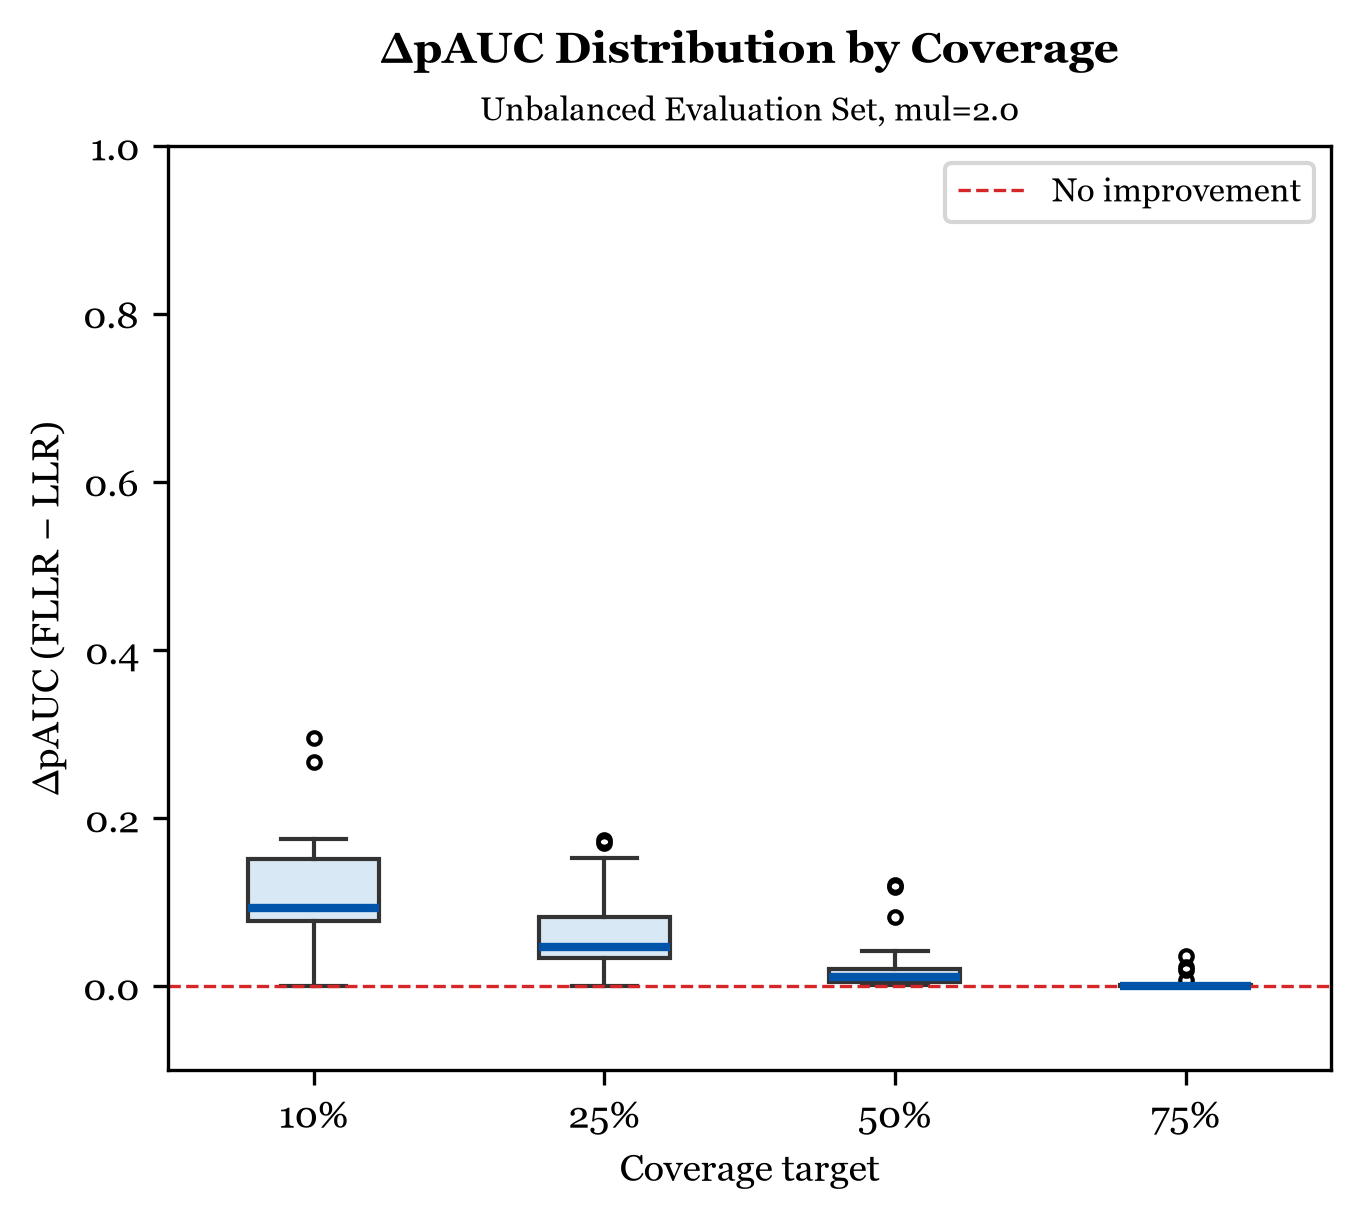

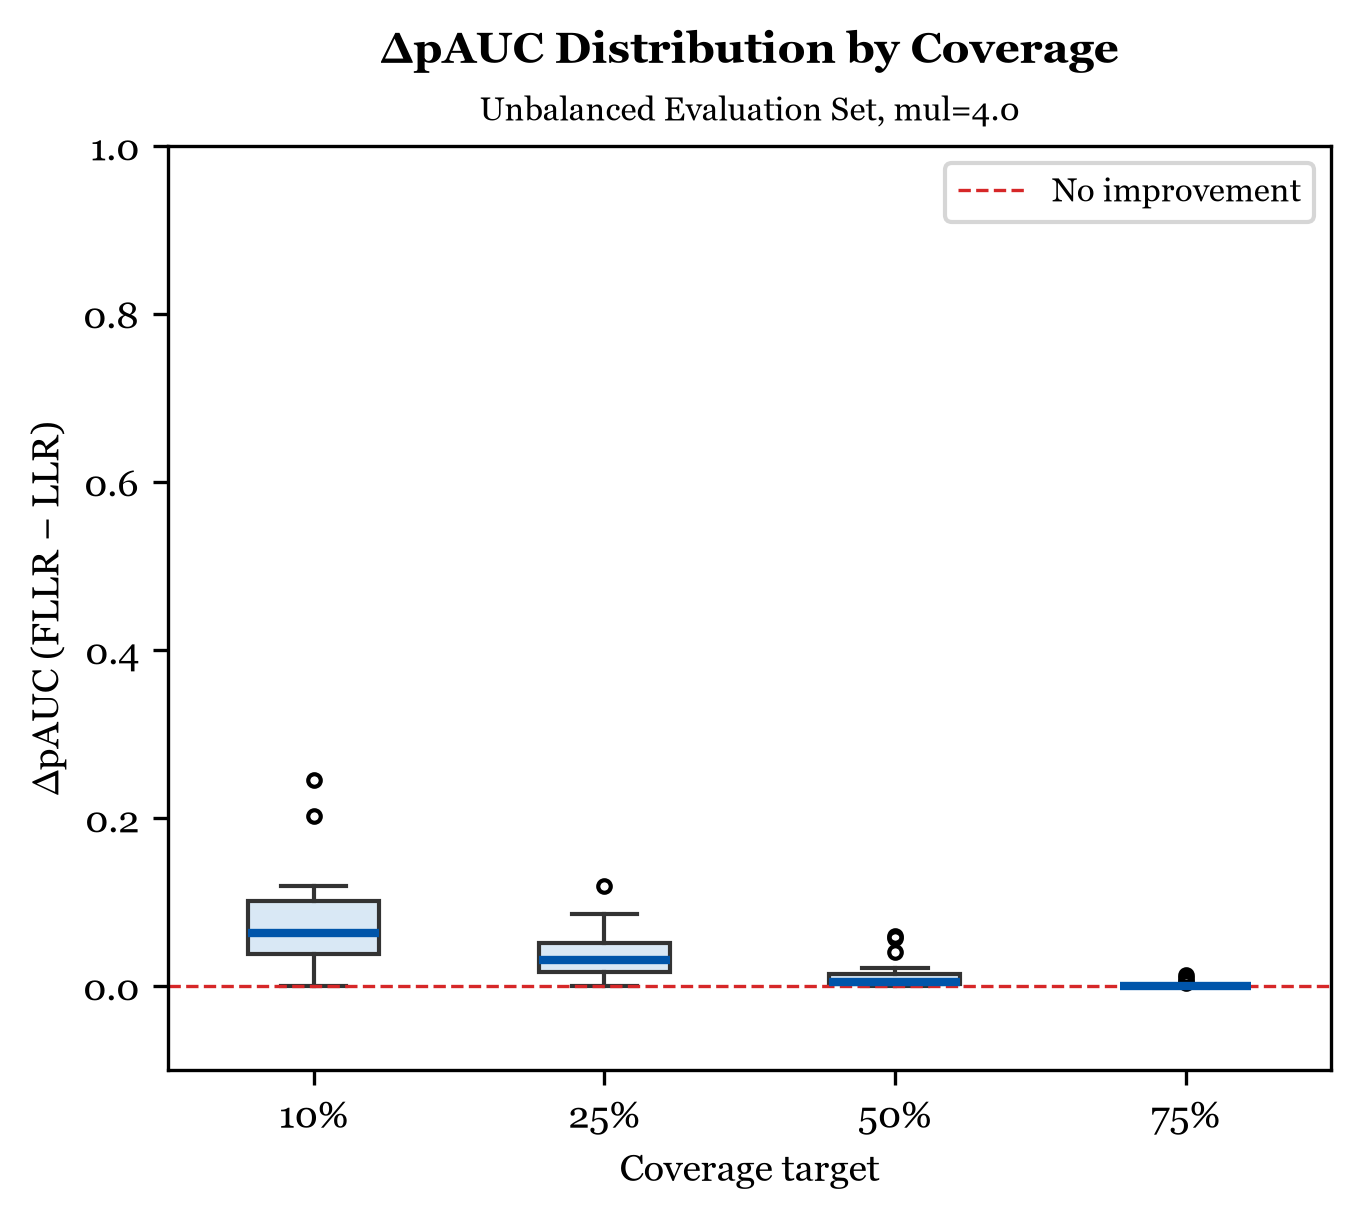

In [8]:
COLOR_POS  = "#2A9D8F"
COLOR_NEG  = "#E63946"
COLOR_ZERO = "#F8F8F8"
FONT       = "Georgia" 
VMAX       = 0.30

cmap = mcolors.LinearSegmentedColormap.from_list(
    "thesis_div", [COLOR_NEG, COLOR_ZERO, COLOR_POS], N=512)

plt.rcParams.update({
    "font.family":  FONT,
    "font.size":    9,
    "figure.dpi":   300,
    "savefig.dpi":  300,
    "savefig.bbox": "tight",
})

VMAX_BOX = 0.3
fig_w, fig_h = 5, 4

EVAL_VARIANTS = [
    (df_balanced,   df_pivot_balanced,   "balanced",   "Balanced Evaluation Set"),
    (df_unbalanced, df_pivot_unbalanced, "unbalanced", "Unbalanced Evaluation Set"),
]

for df, df_pivot, tag, eval_label in EVAL_VARIANTS:
    for mul in df_pivot.columns:
        fig, ax = plt.subplots(figsize=(fig_w, fig_h))

        coverages_u = df[df["Multiplier"] == float(mul.split("=")[1])]["Coverage"].unique()
        coverages_u = sorted(coverages_u, key=lambda x: int(x.replace("%", "")))

        data = [
            df[
                (df["Multiplier"] == float(mul.split("=")[1])) &
                (df["Coverage"] == cov)
            ]["ΔAUC"].dropna().values
            for cov in coverages_u
        ]

        ax.boxplot(data, tick_labels=coverages_u, patch_artist=True,
                   boxprops=dict(facecolor="#d9e8f5", color="#333"),
                   medianprops=dict(color="#0055aa", linewidth=2),
                   whiskerprops=dict(color="#333"),
                   capprops=dict(color="#333"),
                   flierprops=dict(marker="o", markersize=3, color="#999"))

        ax.axhline(0, color="#D62728", linewidth=0.8, linestyle="--", label="No improvement")
        ax.set_xlabel("Coverage target")
        ax.set_ylabel("ΔpAUC (FLLR − LLR)")
        ax.set_title(
            f"ΔpAUC Distribution by Coverage",
            fontweight="bold", fontsize=10.5, pad=20
        )
        ax.text(
            0.5, 1.02,
            f"{eval_label}, {mul}",
            transform=ax.transAxes,
            ha="center", va="bottom",
            fontsize=8, color="#000000", #fontstyle="italic"
        )
        ax.legend(fontsize=8)
        ax.set_ylim(-0.1, 1.0)

        plt.savefig(f"boxplot_{mul}_{tag}.png", bbox_inches="tight", dpi=150, pad_inches=0)
        plt.show()